# GNN Training Setup
This notebook sets up the environment for training Graph Neural Networks using PyTorch Geometric (PyG).

In [2]:
# Install PyTorch Geometric and dependencies
import torch

# Get the torch version to ensure compatibility
TORCH = torch.__version__.split('+')[0]
CUDA = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'

print(f"Installing PyG for Torch {TORCH} with {CUDA}...")

!pip install torch-scatter -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-geometric

Installing PyG for Torch 2.11.0 with cu128...
Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.3 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 31.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 84.5 MB/s eta 0:00:00


In [3]:
import torch
import pandas as pd

In [4]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 20.8 MB/s eta 0:00:00


In [15]:
df_herg = pd.read_parquet("/content/drive/MyDrive/datasets/after_eda/hERG_meta.parquet")
print(len(df_herg))
print(df_herg.columns)
df_bace = pd.read_parquet("/content/drive/MyDrive/datasets/after_eda/BACE1_meta.parquet")
print(len(df_bace))
print(df_bace.columns)

10454
Index(['canonical_smiles', 'target', 'graph_data', 'chembl_id', 'mw_freebase',
       'alogp', 'hba', 'hbd', 'psa', 'rtb', 'num_ro5_violations', 'type_AC50',
       'type_EC50', 'type_IC50', 'type_Kd', 'type_Ki', 'bao_BAO_0000019',
       'bao_BAO_0000218', 'bao_BAO_0000219', 'bao_BAO_0000221',
       'bao_BAO_0000249', 'bao_BAO_0000357', 'org_Canis familiaris',
       'org_Cavia porcellus', 'org_Homo sapiens'],
      dtype='object')
12097
Index(['canonical_smiles', 'target', 'graph_data', 'chembl_id', 'mw_freebase',
       'alogp', 'hba', 'hbd', 'psa', 'rtb', 'num_ro5_violations', 'type_EC50',
       'type_IC50', 'type_Kd', 'type_Ki', 'bao_BAO_0000019', 'bao_BAO_0000218',
       'bao_BAO_0000219', 'bao_BAO_0000221', 'bao_BAO_0000249',
       'bao_BAO_0000357', 'org_Cricetulus griseus', 'org_Homo sapiens',
       'org_Mus musculus', 'org_Rattus norvegicus'],
      dtype='object')


In [16]:
df = df_herg

In [17]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import numpy as np

def generate_scaffolds(df, smiles_col='canonical_smiles'):
    scaffolds = {}
    for i, smiles in enumerate(df[smiles_col]):
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
            if scaffold not in scaffolds:
                scaffolds[scaffold] = []
            scaffolds[scaffold].append(i)
    return scaffolds

def scaffold_split(df, train_frac=0.8, val_frac=0.1, test_frac=0.1):
    assert train_frac + val_frac + test_frac == 1.0

    scaffolds = generate_scaffolds(df)

    scaffold_sets = [
        idx_list for scaffold, idx_list in sorted(scaffolds.items(), key=lambda x: len(x[1]), reverse=True)
    ]

    train_idx, val_idx, test_idx = [], [], []
    train_cutoff = int(train_frac * len(df))
    val_cutoff = train_cutoff + int(val_frac * len(df))

    for scaffold_set in scaffold_sets:
        if len(train_idx) + len(scaffold_set) > train_cutoff:
            if len(train_idx) + len(val_idx) + len(scaffold_set) > val_cutoff:
                test_idx.extend(scaffold_set)
            else:
                val_idx.extend(scaffold_set)
        else:
            train_idx.extend(scaffold_set)

    return df.iloc[train_idx], df.iloc[val_idx], df.iloc[test_idx]

train_df, val_df, test_df = scaffold_split(df_herg)
print(f"Podział Scaffold: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

Podział Scaffold: Train=8363, Val=1045, Test=1046


In [18]:
# RANDOM SPLIT
from sklearn.model_selection import train_test_split

train_random, temp_random = train_test_split(df, test_size=0.2, random_state=42)

val_random, test_random = train_test_split(temp_random, test_size=0.5, random_state=42)

print(f"Treningowy: {len(train_random)} | Walidacyjny: {len(val_random)} | Testowy: {len(test_random)}")

Treningowy: 8363 | Walidacyjny: 1045 | Testowy: 1046


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# 1. PRZYGOTOWANIE DANYCH DLA MLP (BASELINE) - RANDOM SPLIT
# ==============================================================================

ignore_cols_mlp = ['canonical_smiles', 'target', 'graph_data', 'chembl_id']

feature_cols = [c for c in train_random.columns if c not in ignore_cols_mlp]
print(f"Liczba cech przed czyszczeniem typów: {len(feature_cols)}")


for df_split in [train_random, val_random, test_random]:
    for col in feature_cols:
        df_split[col] = pd.to_numeric(df_split[col], errors='coerce').fillna(0.0)

def df_to_tensor_dataset(df, feature_cols, target_col='target'):
    """Konwertuje DataFrame Pandas na PyTorch TensorDataset."""
    X = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y = torch.tensor(df[target_col].values, dtype=torch.float32).view(-1, 1)
    return TensorDataset(X, y)

train_dataset_mlp = df_to_tensor_dataset(train_random, feature_cols)
val_dataset_mlp = df_to_tensor_dataset(val_random, feature_cols)
test_dataset_mlp = df_to_tensor_dataset(test_random, feature_cols)

batch_size = 128
train_loader_mlp = DataLoader(train_dataset_mlp, batch_size=batch_size, shuffle=True)
val_loader_mlp = DataLoader(val_dataset_mlp, batch_size=batch_size, shuffle=False)
test_loader_mlp = DataLoader(test_dataset_mlp, batch_size=batch_size, shuffle=False)

print(f"Ilość batchy treningowych: {len(train_loader_mlp)}")

Liczba cech przed czyszczeniem typów: 21
Ilość batchy treningowych: 66


In [20]:
# ==============================================================================
# 2. DEFINICJA SIECI MLP (BASELINE)
# ==============================================================================

class BaselineMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim_1=256, hidden_dim_2=128):
        super(BaselineMLP, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim_1)
        self.bn1 = nn.BatchNorm1d(hidden_dim_1)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(hidden_dim_1, hidden_dim_2)
        self.bn2 = nn.BatchNorm1d(hidden_dim_2)
        self.dropout2 = nn.Dropout(0.3)

        self.out = nn.Linear(hidden_dim_2, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout2(x)

        return self.out(x)

input_dimension = len(feature_cols)
model_mlp = BaselineMLP(input_dim=input_dimension)
print(model_mlp)

BaselineMLP(
  (fc1): Linear(in_features=21, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (out): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
# ==============================================================================
# 3. SANITY CHECK (TEST OVERFITTINGU NA 1 BATCHU)
# ==============================================================================

def sanity_check_mlp(model, single_batch_X, single_batch_y, epochs=100):
    import copy
    test_model = copy.deepcopy(model)
    test_model.train()

    optimizer = optim.Adam(test_model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = test_model(single_batch_X)
        loss = criterion(predictions, single_batch_y)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 20 == 0 or epoch == epochs - 1:
            print(f"Epoka {epoch+1:>3}/{epochs} | MSE Loss: {loss.item():.4f}")

single_batch_X, single_batch_y = next(iter(DataLoader(train_dataset_mlp, batch_size=32, shuffle=True)))

sanity_check_mlp(model_mlp, single_batch_X, single_batch_y, epochs=150)

Epoka  20/150 | MSE Loss: 1.7625
Epoka  40/150 | MSE Loss: 0.7343
Epoka  60/150 | MSE Loss: 0.5573
Epoka  80/150 | MSE Loss: 0.4129
Epoka 100/150 | MSE Loss: 0.4062
Epoka 120/150 | MSE Loss: 0.2672
Epoka 140/150 | MSE Loss: 0.2788
Epoka 150/150 | MSE Loss: 0.2767


In [21]:
# ==============================================================================
# 4. GŁÓWNA FUNKCJA TRENINGU MLP ZE SCHEDULEREM (POPRAWIONA)
# ==============================================================================
from sklearn.metrics import r2_score

def train_eval_mlp(model, train_loader, val_loader, epochs=50, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    history = {'train_loss': [], 'val_loss': [], 'val_r2': []}

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🔥 Trenuję na urządzeniu: {device}")
    model.to(device)

    for epoch in range(epochs):
        # ---------- TRENING ----------
        model.train()
        train_loss = 0.0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

        train_loss = train_loss / len(train_loader.dataset)
        history['train_loss'].append(train_loss)

        # ---------- WALIDACJA ----------
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                predictions = model(batch_X)

                loss = criterion(predictions, batch_y)
                val_loss += loss.item() * batch_X.size(0)

                all_preds.extend(predictions.cpu().numpy())
                all_targets.extend(batch_y.cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        history['val_loss'].append(val_loss)

        # Obliczenie R2
        r2 = r2_score(np.array(all_targets), np.array(all_preds))
        history['val_r2'].append(r2)

        # ---------- AKTUALIZACJA SCHEDULERA ----------
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoka {epoch+1:03d}/{epochs} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val R2: {r2:.4f}")

    return history

history_mlp = train_eval_mlp(model_mlp, train_loader_mlp, val_loader_mlp, epochs=50)

🔥 Trenuję na urządzeniu: cuda
Epoka 001/50 | LR: 0.001000 | Train Loss: 16.0527 | Val Loss: 6.2455 | Val R2: -6.1945
Epoka 005/50 | LR: 0.001000 | Train Loss: 1.1056 | Val Loss: 0.8221 | Val R2: 0.0530
Epoka 010/50 | LR: 0.001000 | Train Loss: 1.0264 | Val Loss: 0.8050 | Val R2: 0.0727
Epoka 015/50 | LR: 0.001000 | Train Loss: 0.9543 | Val Loss: 0.7140 | Val R2: 0.1775
Epoka 020/50 | LR: 0.001000 | Train Loss: 0.9364 | Val Loss: 0.7310 | Val R2: 0.1579
Epoka 025/50 | LR: 0.001000 | Train Loss: 0.9474 | Val Loss: 0.6921 | Val R2: 0.2027
Epoka 030/50 | LR: 0.001000 | Train Loss: 0.9133 | Val Loss: 0.7301 | Val R2: 0.1590
Epoka 035/50 | LR: 0.001000 | Train Loss: 0.8919 | Val Loss: 0.6746 | Val R2: 0.2229
Epoka 040/50 | LR: 0.001000 | Train Loss: 0.8773 | Val Loss: 0.6662 | Val R2: 0.2326
Epoka 045/50 | LR: 0.001000 | Train Loss: 0.8457 | Val Loss: 0.6651 | Val R2: 0.2339
Epoka 050/50 | LR: 0.000500 | Train Loss: 0.8325 | Val Loss: 0.6750 | Val R2: 0.2224


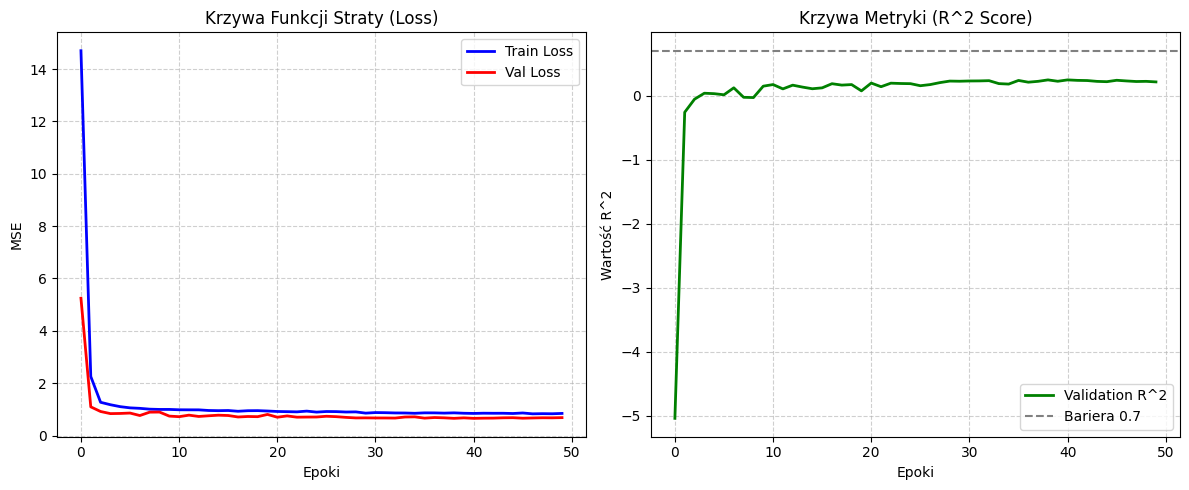

In [ ]:
# ==============================================================================
# 5. WIZUALIZACJA KRZYWYCH UCZENIA I OVERFITTINGU
# ==============================================================================

plt.figure(figsize=(12, 5))

# Wykres funkcji straty (MSE Loss)
plt.subplot(1, 2, 1)
plt.plot(history_mlp['train_loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history_mlp['val_loss'], label='Val Loss', color='red', linewidth=2)
plt.title('Krzywa Funkcji Straty (Loss)')
plt.xlabel('Epoki')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Wykres metryki R2 (Skuteczność przewidywania)
plt.subplot(1, 2, 2)
plt.plot(history_mlp['val_r2'], label='Validation R^2', color='green', linewidth=2)
plt.title('Krzywa Metryki (R^2 Score)')
plt.xlabel('Epoki')
plt.ylabel('Wartość R^2')
# R2 blisko 0.7-0.75 jest super.
plt.axhline(y=0.7, color='grey', linestyle='--', label='Bariera 0.7')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [22]:
train_scaffold, val_scaffold, test_scaffold = train_df, val_df, test_df

In [23]:
# ==============================================================================
# 6. KONWERSJA DANYCH (JSON -> PYTORCH GEOMETRIC) - SCAFFOLD SPLIT
# ==============================================================================
import json
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def df_to_graph_dataset(df, tabular_cols, target_col='target'):
    """Konwertuje kolumnę z JSON-em na listę grafów PyTorch Geometric."""
    dataset = []

    for idx, row in df.iterrows():
        try:
            graph_dict = json.loads(row['graph_data'])
            node_features = []
            for atom in graph_dict['atoms']:
                feat = [
                    atom['atomic_num'],
                    atom['formal_charge'],
                    float(atom['is_aromatic'])
                ]
                node_features.append(feat)

            x = torch.tensor(node_features, dtype=torch.float32)

            edge_src = [bond['source'] for bond in graph_dict['bonds']]
            edge_dst = [bond['target'] for bond in graph_dict['bonds']]

            edge_index = torch.tensor([edge_src + edge_dst, edge_dst + edge_src], dtype=torch.long)

            y = torch.tensor([row[target_col]], dtype=torch.float32)

            tab_x = torch.tensor([row[tabular_cols].values.astype(float)], dtype=torch.float32)

            data = Data(x=x, edge_index=edge_index, y=y, tabular_x=tab_x)
            dataset.append(data)

        except Exception as e:
            continue

    return dataset

train_graphs = df_to_graph_dataset(train_scaffold, feature_cols)
val_graphs = df_to_graph_dataset(val_scaffold, feature_cols)
test_graphs = df_to_graph_dataset(test_scaffold, feature_cols)

print(f"Grafy treningowe: {len(train_graphs)}, Walidacyjne: {len(val_graphs)}")

batch_size_gnn = 128
train_loader_gnn = DataLoader(train_graphs, batch_size=batch_size_gnn, shuffle=True)
val_loader_gnn = DataLoader(val_graphs, batch_size=batch_size_gnn, shuffle=False)
test_loader_gnn = DataLoader(test_graphs, batch_size=batch_size_gnn, shuffle=False)

Grafy treningowe: 8363, Walidacyjne: 1045


In [24]:
# ==============================================================================
# 7. DEFINICJA SIECI GRAFOWEJ (GCN + Tabular)
# ==============================================================================
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class HybridGCN(torch.nn.Module):
    def __init__(self, num_node_features, num_tabular_features, hidden_dim=128):
        super(HybridGCN, self).__init__()

        # --- BLOK GRAFOWY (Czytanie cząsteczki) ---
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)

        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)

        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = torch.nn.BatchNorm1d(hidden_dim)

        # --- BLOK POŁĄCZENIA ---
        combined_dim = hidden_dim + num_tabular_features

        self.fc1 = torch.nn.Linear(combined_dim, hidden_dim)
        self.dropout = torch.nn.Dropout(0.3)
        self.out = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch, tabular_x):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)

        x = global_mean_pool(x, batch)

        # Dodanie cech fizykochemicznych (MW, LogP) do struktury
        x = torch.cat([x, tabular_x], dim=1)

        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        return self.out(x)

# Inicjalizacja modelu
# Wektor węzła ma 3 cechy: [Liczba atomowa, Ładunek, Aromatyczność]
num_node_feats = 3
num_tab_feats = len(feature_cols)

model_gcn = HybridGCN(num_node_feats, num_tab_feats)
print(model_gcn)

HybridGCN(
  (conv1): GCNConv(3, 128)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(128, 128)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GCNConv(128, 128)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=149, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (out): Linear(in_features=128, out_features=1, bias=True)
)


In [25]:
# ==============================================================================
# 8. GŁÓWNA FUNKCJA TRENINGU GNN (GCN) ZE SCHEDULEREM
# ==============================================================================
from sklearn.metrics import r2_score
import torch.optim as optim
import numpy as np

def train_eval_gnn(model, train_loader, val_loader, epochs=50, lr=0.001):
    criterion = torch.nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Scheduler: zmniejsza LR o połowę, gdy błąd na walidacji nie spada przez 5 epok
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    history = {'train_loss': [], 'val_loss': [], 'val_r2': []}

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🔥 Trenuję hybrydowy GNN na urządzeniu: {device}")
    model.to(device)

    for epoch in range(epochs):
        # ---------- TRENING ----------
        model.train()
        train_loss = 0.0

        for data in train_loader:
            data = data.to(device)

            optimizer.zero_grad()

            # Przekazujemy wszystkie 4 komponenty do sieci (Węzły, Krawędzie, Batching, Cechy Tabelaryczne)
            predictions = model(data.x, data.edge_index, data.batch, data.tabular_x)

            # data.y może mieć zły wymiar, wymuszamy kolumnę (N, 1)
            loss = criterion(predictions, data.y.view(-1, 1))
            loss.backward()
            optimizer.step()

            # data.num_graphs to liczba grafów w pojedynczym batchu
            train_loss += loss.item() * data.num_graphs

        train_loss = train_loss / len(train_loader.dataset)
        history['train_loss'].append(train_loss)

        # ---------- WALIDACJA ----------
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)

                predictions = model(data.x, data.edge_index, data.batch, data.tabular_x)
                loss = criterion(predictions, data.y.view(-1, 1))
                val_loss += loss.item() * data.num_graphs

                all_preds.extend(predictions.cpu().numpy())
                all_targets.extend(data.y.view(-1, 1).cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        history['val_loss'].append(val_loss)

        # Obliczenie R2
        r2 = r2_score(np.array(all_targets), np.array(all_preds))
        history['val_r2'].append(r2)

        # Aktualizacja schedulera
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoka {epoch+1:03d}/{epochs} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val R2: {r2:.4f}")

    return history

# Uruchomienie pełnego treningu GCN na 60 epok
history_gcn = train_eval_gnn(model_gcn, train_loader_gnn, val_loader_gnn, epochs=60)

🔥 Trenuję hybrydowy GNN na urządzeniu: cuda
Epoka 001/60 | LR: 0.001000 | Train Loss: 5.1482 | Val Loss: 3.2014 | Val R2: -3.4063
Epoka 005/60 | LR: 0.001000 | Train Loss: 1.0644 | Val Loss: 0.6843 | Val R2: 0.0582
Epoka 010/60 | LR: 0.001000 | Train Loss: 0.9357 | Val Loss: 0.6356 | Val R2: 0.1252
Epoka 015/60 | LR: 0.001000 | Train Loss: 0.8856 | Val Loss: 0.8845 | Val R2: -0.2174
Epoka 020/60 | LR: 0.001000 | Train Loss: 0.8581 | Val Loss: 0.8601 | Val R2: -0.1838
Epoka 025/60 | LR: 0.000500 | Train Loss: 0.8044 | Val Loss: 0.5899 | Val R2: 0.1881
Epoka 030/60 | LR: 0.000250 | Train Loss: 0.7903 | Val Loss: 0.5609 | Val R2: 0.2280
Epoka 035/60 | LR: 0.000250 | Train Loss: 0.7731 | Val Loss: 0.6537 | Val R2: 0.1002
Epoka 040/60 | LR: 0.000125 | Train Loss: 0.7538 | Val Loss: 0.5438 | Val R2: 0.2515
Epoka 045/60 | LR: 0.000125 | Train Loss: 0.7501 | Val Loss: 0.5644 | Val R2: 0.2231
Epoka 050/60 | LR: 0.000063 | Train Loss: 0.7246 | Val Loss: 0.5450 | Val R2: 0.2499
Epoka 055/60 | LR:

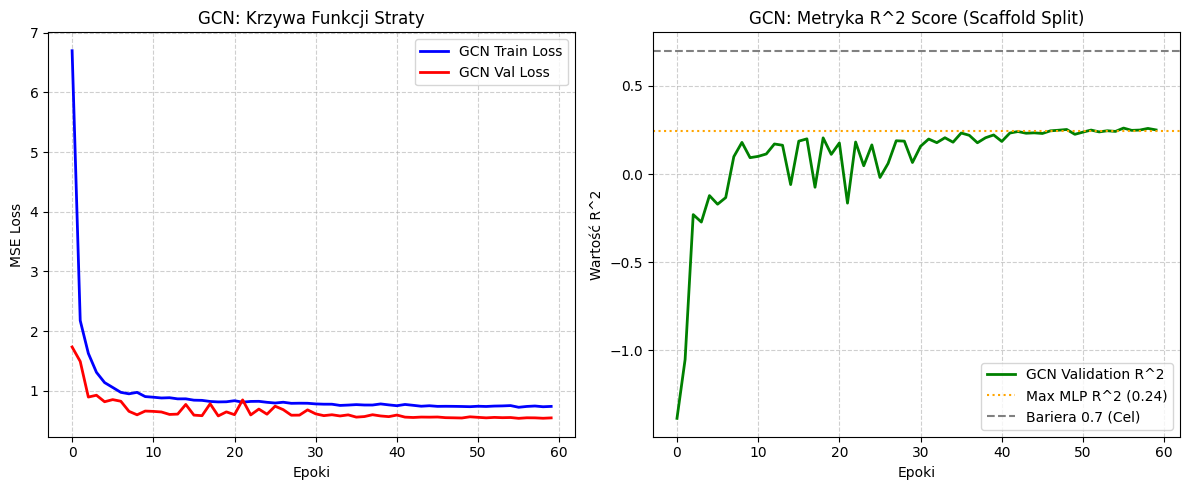

In [ ]:
# ==============================================================================
# 9. WIZUALIZACJA WYNIKÓW GNN (GCN) Z LINIĄ ODNIESIENIA MLP
# ==============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Wykres funkcji straty
plt.subplot(1, 2, 1)
plt.plot(history_gcn['train_loss'], label='GCN Train Loss', color='blue', linewidth=2)
plt.plot(history_gcn['val_loss'], label='GCN Val Loss', color='red', linewidth=2)
plt.title('GCN: Krzywa Funkcji Straty')
plt.xlabel('Epoki')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Wykres metryki R2
plt.subplot(1, 2, 2)
plt.plot(history_gcn['val_r2'], label='GCN Validation R^2', color='green', linewidth=2)

# Linia R2 z modelu MLP (Random Split) dla bezpośredniego porównania
max_mlp_r2 = max(history_mlp['val_r2'])
plt.axhline(y=max_mlp_r2, color='orange', linestyle=':', label=f"Max MLP R^2 ({max_mlp_r2:.2f})")


plt.axhline(y=0.7, color='grey', linestyle='--', label='Bariera 0.7 (Cel)')

plt.title('GCN: Metryka R^2 Score (Scaffold Split)')
plt.xlabel('Epoki')
plt.ylabel('Wartość R^2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [26]:
# ==============================================================================
# 10. DEFINICJA SIECI GRAFOWEJ GIN (Graph Isomorphism Network)
# ==============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool

class HybridGIN(torch.nn.Module):
    def __init__(self, num_node_features, num_tabular_features, hidden_dim=128):
        super(HybridGIN, self).__init__()

        # GIN wymaga zdefiniowania mini-sieci MLP (Multi-Layer Perceptron)
        # wewnątrz każdej warstwy grafowej

        nn1 = nn.Sequential(
            nn.Linear(num_node_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        # eps=0 pozwala sieci samej uczyć się wagi atomu centralnego
        self.conv1 = GINConv(nn1, train_eps=True)
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        nn2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv2 = GINConv(nn2, train_eps=True)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        nn3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv3 = GINConv(nn3, train_eps=True)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        # Blok połączenia (Graf + Tabela)
        combined_dim = hidden_dim + num_tabular_features

        self.fc1 = nn.Linear(combined_dim, hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch, tabular_x):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)

        x = global_add_pool(x, batch)

        x = torch.cat([x, tabular_x], dim=1)

        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        return self.out(x)

model_gin = HybridGIN(num_node_feats, num_tab_feats)
print(model_gin)

HybridGIN(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (b

In [ ]:
# ==============================================================================
# 11. TRENING GIN I ZESTAWIENIE MODELI (GCN vs GIN vs MLP)
# ==============================================================================

print(f"Trenuję GIN na urządzeniu")
history_gin = train_eval_gnn(model_gin, train_loader_gnn, val_loader_gnn, epochs=80, lr=0.001)

Trenuję GIN na urządzeniu
🔥 Trenuję hybrydowy GNN na urządzeniu: cuda
Epoka 001/80 | LR: 0.001000 | Train Loss: 6.4571 | Val Loss: 2.3192 | Val R2: -2.1921
Epoka 005/80 | LR: 0.001000 | Train Loss: 1.3150 | Val Loss: 0.8728 | Val R2: -0.2013
Epoka 010/80 | LR: 0.001000 | Train Loss: 0.9618 | Val Loss: 0.7784 | Val R2: -0.0714
Epoka 015/80 | LR: 0.001000 | Train Loss: 0.8188 | Val Loss: 0.6274 | Val R2: 0.1365
Epoka 020/80 | LR: 0.001000 | Train Loss: 0.7840 | Val Loss: 0.6053 | Val R2: 0.1668
Epoka 025/80 | LR: 0.001000 | Train Loss: 0.6946 | Val Loss: 0.6952 | Val R2: 0.0432
Epoka 030/80 | LR: 0.001000 | Train Loss: 0.6736 | Val Loss: 0.5873 | Val R2: 0.1916
Epoka 035/80 | LR: 0.000500 | Train Loss: 0.5984 | Val Loss: 0.4732 | Val R2: 0.3487
Epoka 040/80 | LR: 0.000500 | Train Loss: 0.5623 | Val Loss: 0.5259 | Val R2: 0.2762
Epoka 045/80 | LR: 0.000250 | Train Loss: 0.5242 | Val Loss: 0.4392 | Val R2: 0.3955
Epoka 050/80 | LR: 0.000250 | Train Loss: 0.5102 | Val Loss: 0.4728 | Val R2:

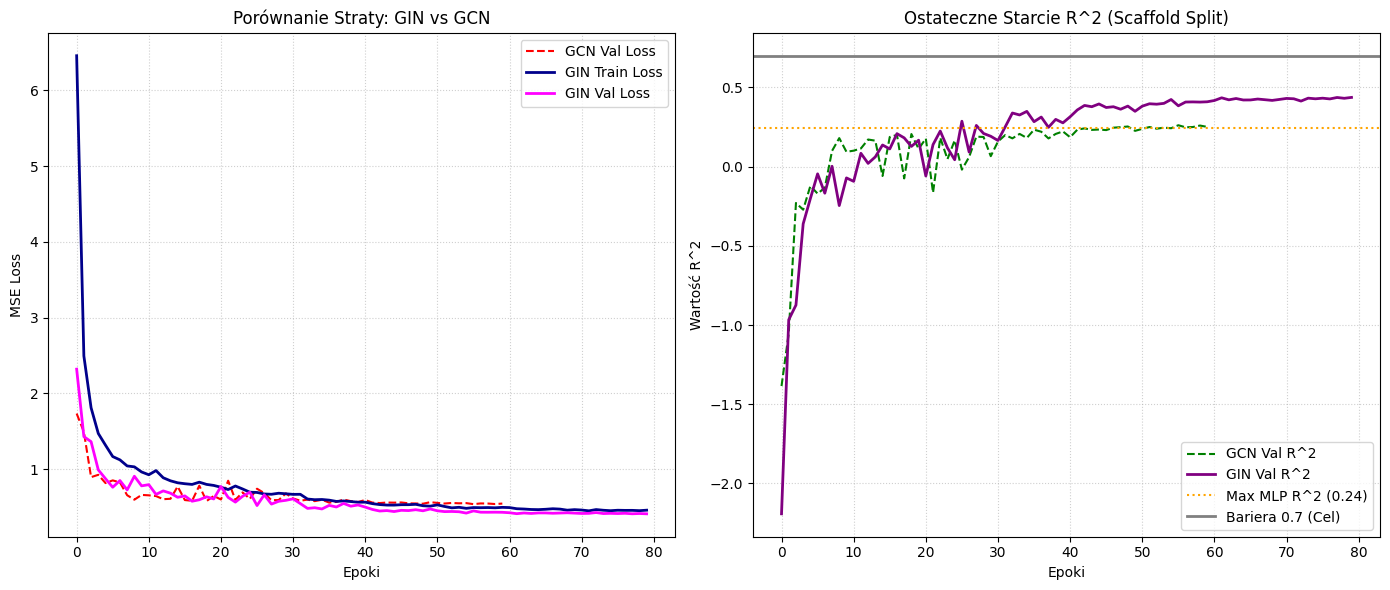

🏆 Maksymalny R2 dla GCN: 0.2612
🏆 Maksymalny R2 dla GIN: 0.4369


In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history_gcn['val_loss'], label='GCN Val Loss', color='red', linestyle='--')
plt.plot(history_gin['train_loss'], label='GIN Train Loss', color='darkblue', linewidth=2)
plt.plot(history_gin['val_loss'], label='GIN Val Loss', color='magenta', linewidth=2)
plt.title('Porównanie Straty: GIN vs GCN')
plt.xlabel('Epoki')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history_gcn['val_r2'], label='GCN Val R^2', color='green', linestyle='--')
plt.plot(history_gin['val_r2'], label='GIN Val R^2', color='purple', linewidth=2)

plt.axhline(y=max_mlp_r2, color='orange', linestyle=':', label=f"Max MLP R^2 ({max_mlp_r2:.2f})")
plt.axhline(y=0.7, color='grey', linestyle='-', linewidth=2, label='Bariera 0.7 (Cel)')

plt.title('Ostateczne Starcie R^2 (Scaffold Split)')
plt.xlabel('Epoki')
plt.ylabel('Wartość R^2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"🏆 Maksymalny R2 dla GCN: {max(history_gcn['val_r2']):.4f}")
print(f"🏆 Maksymalny R2 dla GIN: {max(history_gin['val_r2']):.4f}")

In [ ]:
import torch

torch.save(model_gin.state_dict(), 'gin_bace1_model.pth')
print("✅ Model GIN zapisany pomyślnie jako 'gin_bace1_model.pth'")

✅ Model GIN zapisany pomyślnie jako 'gin_bace1_model.pth'


**Wzbogacamy cechy atomów** (dodajemy stopień, ładunek, hybrydyzację itp.).
**Dodajemy cechy krawędzi** (wiązania pojedyncze, podwójne, aromatyczne).

In [27]:
# ==============================================================================
# 12. ZAAWANSOWANY PARSER GRAFÓW (GINE) - DODANIE CECH WIĄZAŃ
# ==============================================================================
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from rdkit import Chem
import numpy as np

def create_advanced_graph(smiles, tabular_x, target_y):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return None

    # 1. BOGATSZE CECHY ATOMÓW (7 cech)
    node_features = []
    for atom in mol.GetAtoms():
        feat = [
            atom.GetAtomicNum(),
            atom.GetDegree(),                    # Liczba sąsiadów
            atom.GetFormalCharge(),
            atom.GetNumRadicalElectrons(),
            atom.GetHybridization().real,        # Hybrydyzacja
            int(atom.GetIsAromatic()),           # Aromatyczność
            atom.GetMass()                       # Masa
        ]
        node_features.append(feat)
    x = torch.tensor(node_features, dtype=torch.float32)

    edge_indices = []
    edge_attrs = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        bond_type = bond.GetBondType()
        # Kodowanie One-Hot typu wiązania
        bond_feat = [
            float(bond_type == Chem.rdchem.BondType.SINGLE),
            float(bond_type == Chem.rdchem.BondType.DOUBLE),
            float(bond_type == Chem.rdchem.BondType.TRIPLE),
            float(bond_type == Chem.rdchem.BondType.AROMATIC),
            float(bond.GetIsConjugated())
        ]

        # Grafy nieskierowane - krawędź idzie w obu kierunkach
        edge_indices += [[i, j], [j, i]]
        edge_attrs += [bond_feat, bond_feat]

    if len(edge_indices) > 0:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.float32)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 5), dtype=torch.float32)

    y = torch.tensor([[target_y]], dtype=torch.float32)
    tab_x = torch.tensor([tabular_x], dtype=torch.float32)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, tabular_x=tab_x)

def load_advanced_dataset(df, tabular_cols, target_col='target'):
    dataset = []
    for _, row in df.iterrows():
        try:
            tab_x = row[tabular_cols].values.astype(float)
            target = row[target_col]
            graph_data = create_advanced_graph(row['canonical_smiles'], tab_x, target)
            if graph_data:
                dataset.append(graph_data)
        except Exception as e:
            continue
    return dataset

print("⏳ Budowa zaawansowanych grafów GINE (ze Scaffold Splitu)...")
train_graphs_gine = load_advanced_dataset(train_scaffold, feature_cols)
val_graphs_gine = load_advanced_dataset(val_scaffold, feature_cols)
test_graphs_gine = load_advanced_dataset(test_scaffold, feature_cols)

print(f"✅ Przygotowano! Trening: {len(train_graphs_gine)}, Walidacja: {len(val_graphs_gine)}")

batch_size_gine = 128
train_loader_gine = DataLoader(train_graphs_gine, batch_size=batch_size_gine, shuffle=True)
val_loader_gine = DataLoader(val_graphs_gine, batch_size=batch_size_gine, shuffle=False)
test_loader_gine = DataLoader(test_graphs_gine, batch_size=batch_size_gine, shuffle=False)

⏳ Budowa zaawansowanych grafów GINE (ze Scaffold Splitu)...
✅ Przygotowano! Trening: 8363, Walidacja: 1045


In [7]:
# ==============================================================================
# 13. ZAAWANSOWANA ARCHITEKTURA GINE (GRAPH ISOMORPHISM NETWORK + EDGES)
# ==============================================================================
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_add_pool

class HybridGINE(nn.Module):
    def __init__(self, num_node_features, num_edge_features, num_tabular_features, hidden_dim=128):
        super(HybridGINE, self).__init__()

        # Wstępne rzutowanie, żeby węzły i krawędzie miały ten sam wymiar ukryty (wymóg GINEConv)
        self.node_emb = nn.Linear(num_node_features, hidden_dim)
        self.edge_emb1 = nn.Linear(num_edge_features, hidden_dim)
        self.edge_emb2 = nn.Linear(num_edge_features, hidden_dim)
        self.edge_emb3 = nn.Linear(num_edge_features, hidden_dim)

        # 1. Warstwa
        nn1 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(nn1, train_eps=True)
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        # 2. Warstwa
        nn2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv2 = GINEConv(nn2, train_eps=True)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        # 3. Warstwa
        nn3 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv3 = GINEConv(nn3, train_eps=True)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        # Blok MLP
        combined_dim = hidden_dim + num_tabular_features
        self.fc1 = nn.Linear(combined_dim, hidden_dim)
        self.dropout = nn.Dropout(0.2)
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, edge_attr, batch, tabular_x):
        x = self.node_emb(x)

        # Przejścia z krawędziami
        edge_feat1 = self.edge_emb1(edge_attr)
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_feat1)))

        edge_feat2 = self.edge_emb2(edge_attr)
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_feat2)))

        edge_feat3 = self.edge_emb3(edge_attr)
        x = self.conv3(x, edge_index, edge_feat3)
        self.bn3(x)

        # Agregacja i Tabelaryczne
        x = global_add_pool(x, batch)
        x = torch.cat([x, tabular_x], dim=1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.out(x)

# Inicjalizacja z nowymi wymiarami
model_gine = HybridGINE(num_node_features=7, num_edge_features=5, num_tabular_features=len(feature_cols))
print(model_gine)

HybridGINE(
  (node_emb): Linear(in_features=7, out_features=128, bias=True)
  (edge_emb1): Linear(in_features=5, out_features=128, bias=True)
  (edge_emb2): Linear(in_features=5, out_features=128, bias=True)
  (edge_emb3): Linear(in_features=5, out_features=128, bias=True)
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (co

In [29]:
# ==============================================================================
# 14. TRENING GINE I PORÓWNANIE WYNIKÓW
# ==============================================================================
import torch.optim as optim
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

def train_eval_gine(model, train_loader, val_loader, epochs=80, lr=0.001):
    criterion = torch.nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    history = {'train_loss': [], 'val_loss': [], 'val_r2': []}
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    print(f"🔥 Trenuję hybrydowy GINE na urządzeniu: {device}")

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()

            # W GINE przekazujemy również data.edge_attr!
            predictions = model(data.x, data.edge_index, data.edge_attr, data.batch, data.tabular_x)

            loss = criterion(predictions, data.y.view(-1, 1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * data.num_graphs

        train_loss = train_loss / len(train_loader.dataset)
        history['train_loss'].append(train_loss)

        model.eval()
        val_loss = 0.0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                predictions = model(data.x, data.edge_index, data.edge_attr, data.batch, data.tabular_x)

                loss = criterion(predictions, data.y.view(-1, 1))
                val_loss += loss.item() * data.num_graphs
                all_preds.extend(predictions.cpu().numpy())
                all_targets.extend(data.y.view(-1, 1).cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        history['val_loss'].append(val_loss)
        history['val_r2'].append(r2_score(np.array(all_targets), np.array(all_preds)))

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoka {epoch+1:03d}/{epochs} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val R2: {history['val_r2'][-1]:.4f}")

    return history

history_gine = train_eval_gine(model_gine, train_loader_gine, val_loader_gine, epochs=80)

🔥 Trenuję hybrydowy GINE na urządzeniu: cuda


RuntimeError: mat1 and mat2 shapes cannot be multiplied (128x149 and 161x128)

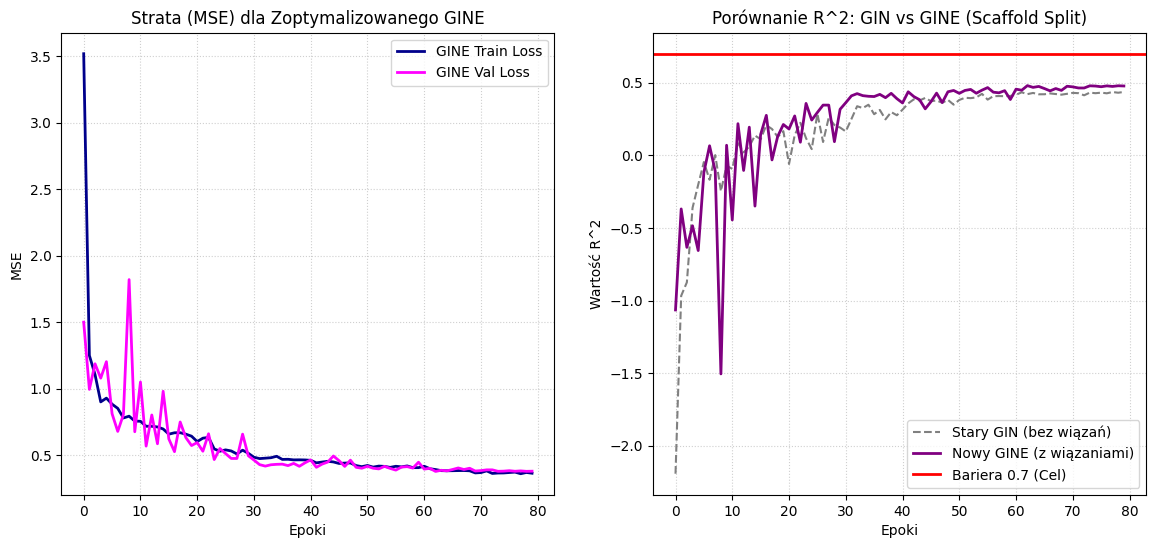

🏆 MAX R2 ZOPTYMALIZOWANEGO GINE: 0.4803


In [ ]:
# ----------------- WIZUALIZACJA -----------------
plt.figure(figsize=(14, 6))

# Wykres Strata
plt.subplot(1, 2, 1)
plt.plot(history_gine['train_loss'], label='GINE Train Loss', color='darkblue', linewidth=2)
plt.plot(history_gine['val_loss'], label='GINE Val Loss', color='magenta', linewidth=2)
plt.title('Strata (MSE) dla Zoptymalizowanego GINE')
plt.xlabel('Epoki')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Wykres R2
plt.subplot(1, 2, 2)
plt.plot(history_gin['val_r2'], label='Stary GIN (bez wiązań)', color='gray', linestyle='--')
plt.plot(history_gine['val_r2'], label='Nowy GINE (z wiązaniami)', color='purple', linewidth=2)
plt.axhline(y=0.7, color='red', linestyle='-', linewidth=2, label='Bariera 0.7 (Cel)')

plt.title('Porównanie R^2: GIN vs GINE (Scaffold Split)')
plt.xlabel('Epoki')
plt.ylabel('Wartość R^2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"🏆 MAX R2 ZOPTYMALIZOWANEGO GINE: {max(history_gine['val_r2']):.4f}")

In [ ]:
# Zapisujemy najlepszy model na koniec!
import copy
best_epoch = np.argmax(history_gine['val_r2'])
print(f"Najlepsza epoka to {best_epoch + 1}.")
torch.save(model_gine.state_dict(), 'gine_optimized_bace1.pth')
print("✅ Zoptymalizowany model zapisano jako 'gine_optimized_bace1.pth'")

Najlepsza epoka to 63.
✅ Zoptymalizowany model zapisano jako 'gine_optimized_bace1.pth'


In [ ]:
# ==============================================================================
# 15. PRZYGOTOWANIE ZAAWANSOWANYCH GRAFÓW DLA RANDOM SPLIT
# ==============================================================================

train_graphs_gine_rand = load_advanced_dataset(train_random, feature_cols)
val_graphs_gine_rand = load_advanced_dataset(val_random, feature_cols)
test_graphs_gine_rand = load_advanced_dataset(test_random, feature_cols)

print(f"Trening: {len(train_graphs_gine_rand)}, Walidacja: {len(val_graphs_gine_rand)}")

batch_size_gine = 128
train_loader_gine_rand = DataLoader(train_graphs_gine_rand, batch_size=batch_size_gine, shuffle=True)
val_loader_gine_rand = DataLoader(val_graphs_gine_rand, batch_size=batch_size_gine, shuffle=False)
test_loader_gine_rand = DataLoader(test_graphs_gine_rand, batch_size=batch_size_gine, shuffle=False)

Trening: 8363, Walidacja: 1045


🔥 Trenuję hybrydowy GINE na urządzeniu: cuda
Epoka 001/80 | LR: 0.001000 | Train Loss: 3.1605 | Val Loss: 1.4039 | Val R2: -0.6172
Epoka 005/80 | LR: 0.001000 | Train Loss: 0.8653 | Val Loss: 0.7939 | Val R2: 0.0855
Epoka 010/80 | LR: 0.001000 | Train Loss: 0.7480 | Val Loss: 0.7091 | Val R2: 0.1832
Epoka 015/80 | LR: 0.000500 | Train Loss: 0.6565 | Val Loss: 0.5668 | Val R2: 0.3471
Epoka 020/80 | LR: 0.000500 | Train Loss: 0.6172 | Val Loss: 0.6612 | Val R2: 0.2383
Epoka 025/80 | LR: 0.000250 | Train Loss: 0.5784 | Val Loss: 0.4725 | Val R2: 0.4557
Epoka 030/80 | LR: 0.000125 | Train Loss: 0.5499 | Val Loss: 0.4723 | Val R2: 0.4559
Epoka 035/80 | LR: 0.000125 | Train Loss: 0.5086 | Val Loss: 0.3992 | Val R2: 0.5402
Epoka 040/80 | LR: 0.000063 | Train Loss: 0.4946 | Val Loss: 0.3773 | Val R2: 0.5654
Epoka 045/80 | LR: 0.000063 | Train Loss: 0.4744 | Val Loss: 0.3833 | Val R2: 0.5585
Epoka 050/80 | LR: 0.000063 | Train Loss: 0.4692 | Val Loss: 0.3834 | Val R2: 0.5584
Epoka 055/80 | LR: 

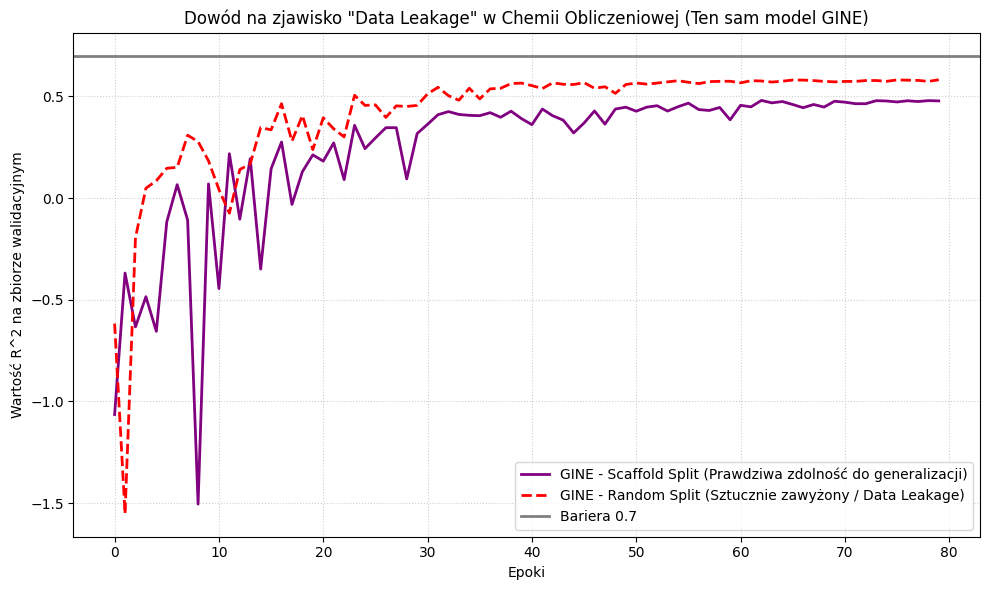


🏆 Prawdziwy MAX R2 (Scaffold Split): 0.4803
🚨 Zawyżony MAX R2 (Random Split):   0.5818


In [ ]:
# ==============================================================================
# 16. TRENING GINE NA RANDOM SPLIT I OSTATECZNE PORÓWNANIE (DATA LEAKAGE)
# ==============================================================================

# 1. Inicjalizujemy całkowicie nową, "pustą" sieć GINE (z losowymi wagami)
model_gine_rand = HybridGINE(num_node_features=7, num_edge_features=5, num_tabular_features=len(feature_cols))

# 2. Trenujemy (używamy tej samej funkcji, ale z nowymi loaderami)
history_gine_rand = train_eval_gine(model_gine_rand, train_loader_gine_rand, val_loader_gine_rand, epochs=80)

# 3. WIZUALIZACJA: Scaffold Split vs Random Split
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Wczytujemy historię z treningu na Scaffold Split (zmienna history_gine z komórki 14)
plt.plot(history_gine['val_r2'], label='GINE - Scaffold Split (Prawdziwa zdolność do generalizacji)', color='purple', linewidth=2)

# Nowa historia na Random Split
plt.plot(history_gine_rand['val_r2'], label='GINE - Random Split (Sztucznie zawyżony / Data Leakage)', color='red', linewidth=2, linestyle='--')

# Nasz docelowy próg z instrukcji prowadzącego
plt.axhline(y=0.7, color='grey', linestyle='-', linewidth=2, label='Bariera 0.7')

plt.title('Dowód na zjawisko "Data Leakage" w Chemii Obliczeniowej (Ten sam model GINE)')
plt.xlabel('Epoki')
plt.ylabel('Wartość R^2 na zbiorze walidacyjnym')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(f"🏆 Prawdziwy MAX R2 (Scaffold Split): {max(history_gine['val_r2']):.4f}")
print(f"🚨 Zawyżony MAX R2 (Random Split):   {max(history_gine_rand['val_r2']):.4f}")
print("="*50)

In [ ]:
# ==============================================================================
# 17. MORGAN FINGERPRINTS (SCAFFOLD SPLIT)
# ==============================================================================
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def create_ultimate_graph(smiles, tabular_x, target_y):
    """Graf GINE + 1024-bitowy Morgan Fingerprint."""
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return None

    # --- 1. MORGAN FINGERPRINTS ---
    # Generujemy ECFP4 (Radius=2), 1024 bity
    morgan_fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    morgan_array = np.array(morgan_fp, dtype=float)

    # Łączymy nasze stare cechy (21) z nowymi bitami (1024) -> Razem 1045 cech!
    ultimate_tabular_x = np.concatenate([tabular_x, morgan_array])

    # --- 2. CECHY ATOMÓW (Jak w GINE) ---
    node_features = []
    for atom in mol.GetAtoms():
        feat = [
            atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
            atom.GetNumRadicalElectrons(), atom.GetHybridization().real,
            int(atom.GetIsAromatic()), atom.GetMass()
        ]
        node_features.append(feat)
    x = torch.tensor(node_features, dtype=torch.float32)

    # --- 3. CECHY WIĄZAŃ (Jak w GINE) ---
    edge_indices = []
    edge_attrs = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_type = bond.GetBondType()
        bond_feat = [
            float(bond_type == Chem.rdchem.BondType.SINGLE),
            float(bond_type == Chem.rdchem.BondType.DOUBLE),
            float(bond_type == Chem.rdchem.BondType.TRIPLE),
            float(bond_type == Chem.rdchem.BondType.AROMATIC),
            float(bond.GetIsConjugated())
        ]
        edge_indices += [[i, j], [j, i]]
        edge_attrs += [bond_feat, bond_feat]

    if len(edge_indices) > 0:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.float32)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 5), dtype=torch.float32)

    y = torch.tensor([[target_y]], dtype=torch.float32)
    tab_x = torch.tensor([ultimate_tabular_x], dtype=torch.float32)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, tabular_x=tab_x)

def load_ultimate_dataset(df, tabular_cols, target_col='target'):
    dataset = []
    for _, row in df.iterrows():
        try:
            tab_x = row[tabular_cols].values.astype(float)
            target = row[target_col]
            graph_data = create_ultimate_graph(row['canonical_smiles'], tab_x, target)
            if graph_data:
                dataset.append(graph_data)
        except Exception as e:
            continue
    return dataset

print("⏳ Budowa ULTIMATE grafów (GINE + Morgan Fingerprints)...")
# Wracamy do rygorystycznego Scaffold Splitu!
train_graphs_ult = load_ultimate_dataset(train_scaffold, feature_cols)
val_graphs_ult = load_ultimate_dataset(val_scaffold, feature_cols)
test_graphs_ult = load_ultimate_dataset(test_scaffold, feature_cols)

print(f"✅ Przygotowano! Wymiar wektora tabular_x to teraz: {train_graphs_ult[0].tabular_x.shape[1]}")

batch_size_ult = 128
train_loader_ult = DataLoader(train_graphs_ult, batch_size=batch_size_ult, shuffle=True)
val_loader_ult = DataLoader(val_graphs_ult, batch_size=batch_size_ult, shuffle=False)
test_loader_ult = DataLoader(test_graphs_ult, batch_size=batch_size_ult, shuffle=False)

⏳ Budowa ULTIMATE grafów (GINE + Morgan Fingerprints)...


Streaming output truncated to the last 5000 lines.
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:01:52] DEPRECATION WARNING: please use MorganGenerator
[17:0

✅ Przygotowano! Wymiar wektora tabular_x to teraz: 1045


[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerator
[17:02:12] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
# ==============================================================================
# 18. TRENING GINE + MORGAN FINGERPRINTS
# ==============================================================================
import matplotlib.pyplot as plt

# Pobieramy nowy wymiar części tabelarycznej bezpośrednio z grafu
new_tabular_dim = train_graphs_ult[0].tabular_x.shape[1]

# Inicjalizujemy świeży model GINE z potężnym wejściem MLP (1045 cech!)
model_gine_ult = HybridGINE(
    num_node_features=7,
    num_edge_features=5,
    num_tabular_features=new_tabular_dim
)

print(f"🚀 Rozpoczynam trening OSTATECZNEJ sieci GINE (Features: {new_tabular_dim})...")

# Używamy zdefiniowanej wcześniej funkcji trenującej (z Komórki 14)
history_gine_ult = train_eval_gine(
    model_gine_ult,
    train_loader_ult,
    val_loader_ult,
    epochs=80
)

🚀 Rozpoczynam trening OSTATECZNEJ sieci GINE (Features: 1045)...
🔥 Trenuję hybrydowy GINE na urządzeniu: cuda
Epoka 001/80 | LR: 0.001000 | Train Loss: 2.4818 | Val Loss: 2.4179 | Val R2: -2.3279
Epoka 005/80 | LR: 0.001000 | Train Loss: 0.6746 | Val Loss: 0.9086 | Val R2: -0.2506
Epoka 010/80 | LR: 0.001000 | Train Loss: 0.5325 | Val Loss: 0.6105 | Val R2: 0.1598
Epoka 015/80 | LR: 0.000500 | Train Loss: 0.4960 | Val Loss: 0.5333 | Val R2: 0.2661
Epoka 020/80 | LR: 0.000500 | Train Loss: 0.4328 | Val Loss: 0.5053 | Val R2: 0.3045
Epoka 025/80 | LR: 0.000500 | Train Loss: 0.4117 | Val Loss: 0.5055 | Val R2: 0.3043
Epoka 030/80 | LR: 0.000500 | Train Loss: 0.3910 | Val Loss: 0.5041 | Val R2: 0.3062
Epoka 035/80 | LR: 0.000250 | Train Loss: 0.3706 | Val Loss: 0.4412 | Val R2: 0.3928
Epoka 040/80 | LR: 0.000250 | Train Loss: 0.3508 | Val Loss: 0.4303 | Val R2: 0.4078
Epoka 045/80 | LR: 0.000125 | Train Loss: 0.3268 | Val Loss: 0.4441 | Val R2: 0.3888
Epoka 050/80 | LR: 0.000125 | Train Lo

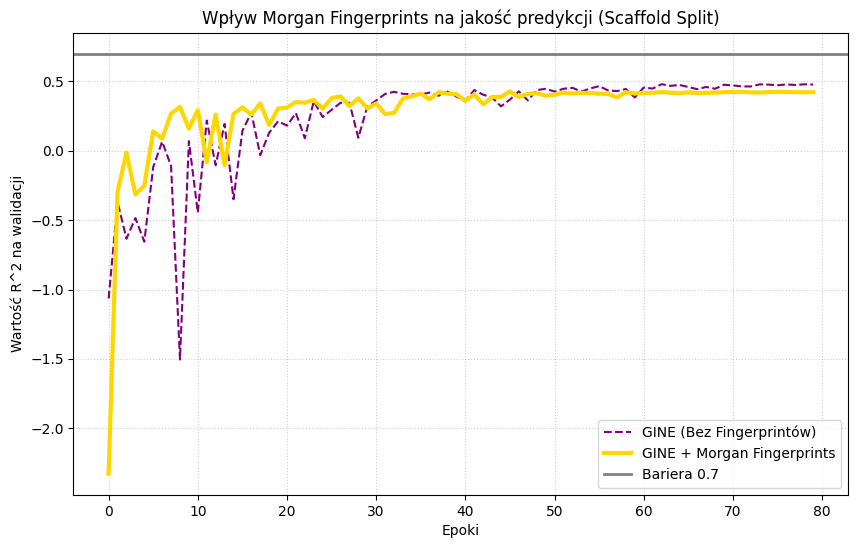


🏆 MAX R2 (Zwykłe GINE):       0.4803
🌟 MAX R2 (GINE + Morgan FP):  0.4287
✅ Zapisano jako 'gine_ultimate_bace1.pth'


In [ ]:
# --- WIZUALIZACJA POSTĘPU ---
plt.figure(figsize=(10, 6))

# Stary wynik bez Fingerprintów
plt.plot(history_gine['val_r2'], label='GINE (Bez Fingerprintów)', color='purple', linestyle='--')

# Nowy wynik z Fingerprintami
plt.plot(history_gine_ult['val_r2'], label='GINE + Morgan Fingerprints', color='gold', linewidth=3)

plt.axhline(y=0.7, color='grey', linestyle='-', linewidth=2, label='Bariera 0.7')

plt.title('Wpływ Morgan Fingerprints na jakość predykcji (Scaffold Split)')
plt.xlabel('Epoki')
plt.ylabel('Wartość R^2 na walidacji')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("\n" + "="*50)
print(f"🏆 MAX R2 (Zwykłe GINE):       {max(history_gine['val_r2']):.4f}")
print(f"🌟 MAX R2 (GINE + Morgan FP):  {max(history_gine_ult['val_r2']):.4f}")
print("="*50)

# Zapiszmy tego potwora
torch.save(model_gine_ult.state_dict(), 'gine_ultimate_bace1notherg.pth')

BACE

In [ ]:
# ==============================================================================
# 19. PRZYGOTOWANIE DANYCH DLA DRUGIEGO BIAŁKA (BACE1) - POPRAWIONE
# ==============================================================================
from torch_geometric.loader import DataLoader
import pandas as pd

print("⏳ Rozpoczynam przetwarzanie zbioru BACE1 (df_bace)...")

# 1. Definiujemy cechy TYLKO dla BACE1 (unikamy błędu brakujących kolumn jak type_AC50)
ignore_cols = ['canonical_smiles', 'target', 'graph_data', 'chembl_id']
feature_cols_bace = [c for c in df_bace.columns if c not in ignore_cols]
print(f"Liczba cech tabelarycznych w BACE1: {len(feature_cols_bace)}")

# 2. Czyszczenie typów kolumn numerycznych dla BACE1
for col in feature_cols_bace:
    df_bace[col] = pd.to_numeric(df_bace[col], errors='coerce').fillna(0.0)

# 3. Rygorystyczny Scaffold Split
train_bace, val_bace, test_bace = scaffold_split(df_bace)
print(f"✅ Podział Scaffold dla BACE1: Train={len(train_bace)}, Val={len(val_bace)}, Test={len(test_bace)}")

# 4. Budowa grafów dla standardowego GINE (Z wiązaniami, bez Morgana)
print("⏳ Konstruowanie grafów topologicznych (GINE)...")
# WAŻNE: Przekazujemy nową listę cech: feature_cols_bace
train_g_bace = load_advanced_dataset(train_bace, feature_cols_bace)
val_g_bace = load_advanced_dataset(val_bace, feature_cols_bace)

loader_train_bace = DataLoader(train_g_bace, batch_size=128, shuffle=True)
loader_val_bace = DataLoader(val_g_bace, batch_size=128, shuffle=False)

# 5. Budowa grafów dla GINE + Morgan Fingerprints
print("⏳ Konstruowanie grafów rozszerzonych (GINE + Morgan FP)...")
train_g_bace_ult = load_ultimate_dataset(train_bace, feature_cols_bace)
val_g_bace_ult = load_ultimate_dataset(val_bace, feature_cols_bace)

loader_train_bace_ult = DataLoader(train_g_bace_ult, batch_size=128, shuffle=True)
loader_val_bace_ult = DataLoader(val_g_bace_ult, batch_size=128, shuffle=False)

print("✅ Wszystkie paczki danych (Loaders) dla białka BACE1 są gotowe do treningu!")

⏳ Rozpoczynam przetwarzanie zbioru BACE1 (df_bace)...
Liczba cech tabelarycznych w BACE1: 21
✅ Podział Scaffold dla BACE1: Train=9677, Val=1209, Test=1211
⏳ Konstruowanie grafów topologicznych (GINE)...
⏳ Konstruowanie grafów rozszerzonych (GINE + Morgan FP)...


Streaming output truncated to the last 5000 lines.
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:17:46] DEPRECATION WARNING: please use MorganGenerator
[17:1

✅ Wszystkie paczki danych (Loaders) dla białka BACE1 są gotowe do treningu!



🚀 [1/2] Trenuję czysty model GINE na białku BACE1...
🔥 Trenuję hybrydowy GINE na urządzeniu: cuda
Epoka 001/60 | LR: 0.001000 | Train Loss: 2.6834 | Val Loss: 1.4297 | Val R2: 0.1538
Epoka 005/60 | LR: 0.001000 | Train Loss: 1.1278 | Val Loss: 1.2382 | Val R2: 0.2671
Epoka 010/60 | LR: 0.001000 | Train Loss: 1.0022 | Val Loss: 1.2921 | Val R2: 0.2352
Epoka 015/60 | LR: 0.001000 | Train Loss: 0.9658 | Val Loss: 3.8258 | Val R2: -1.2645
Epoka 020/60 | LR: 0.000500 | Train Loss: 0.8436 | Val Loss: 1.0296 | Val R2: 0.3906
Epoka 025/60 | LR: 0.000500 | Train Loss: 0.8033 | Val Loss: 1.1628 | Val R2: 0.3117
Epoka 030/60 | LR: 0.000500 | Train Loss: 0.7888 | Val Loss: 1.2715 | Val R2: 0.2474
Epoka 035/60 | LR: 0.000250 | Train Loss: 0.7262 | Val Loss: 0.8862 | Val R2: 0.4755
Epoka 040/60 | LR: 0.000250 | Train Loss: 0.7122 | Val Loss: 0.8734 | Val R2: 0.4830
Epoka 045/60 | LR: 0.000125 | Train Loss: 0.6856 | Val Loss: 0.8050 | Val R2: 0.5235
Epoka 050/60 | LR: 0.000125 | Train Loss: 0.6661 |

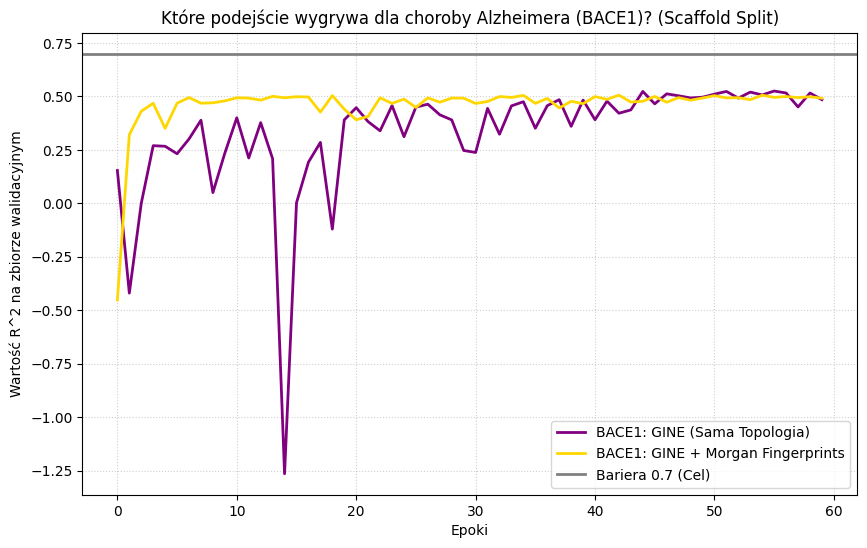


🏆 MAX R2 (BACE1 - Czysty GINE):       0.5255
🌟 MAX R2 (BACE1 - GINE + Morgan):     0.5061
✅ Modele zapisane! Jesteśmy gotowi na Multi-Parameter Optimization w Streamlicie.


In [ ]:
# ==============================================================================
# 20. TRENING OBU WARIANTÓW GINE NA ZBIORZE BACE1 I WIZUALIZACJA
# ==============================================================================
import matplotlib.pyplot as plt
import torch

# --- WARIANT 1: CZYSTY GINE (Tylko Topologia i cechy tabelaryczne BACE1) ---
print("\n🚀 [1/2] Trenuję czysty model GINE na białku BACE1...")

# Inicjalizacja "czystej" sieci z nowym rozmiarem wejścia
model_gine_bace = HybridGINE(
    num_node_features=7,
    num_edge_features=5,
    num_tabular_features=len(feature_cols_bace)
)

# Uruchomienie pętli uczącej
history_bace_gine = train_eval_gine(model_gine_bace, loader_train_bace, loader_val_bace, epochs=60)

# Zapisanie wag
torch.save(model_gine_bace.state_dict(), 'gine_bace1_topology.pth')


# --- WARIANT 2: GINE + MORGAN FINGERPRINTS ---
print("\n🚀 [2/2] Trenuję potężny model (GINE + Morgan) na białku BACE1...")
new_tab_dim_bace = train_g_bace_ult[0].tabular_x.shape[1]

# Inicjalizacja sieci z wielkim wejściem MLP (cechy BACE1 + 1024 z Morgana)
model_gine_bace_ult = HybridGINE(
    num_node_features=7,
    num_edge_features=5,
    num_tabular_features=new_tab_dim_bace
)

# Uruchomienie pętli uczącej
history_bace_ult = train_eval_gine(model_gine_bace_ult, loader_train_bace_ult, loader_val_bace_ult, epochs=60)

# Zapisanie wag
torch.save(model_gine_bace_ult.state_dict(), 'gine_bace1_morgan.pth')


# --- WIZUALIZACJA I PORÓWNANIE ---
plt.figure(figsize=(10, 6))

plt.plot(history_bace_gine['val_r2'], label='BACE1: GINE (Sama Topologia)', color='purple', linewidth=2)
plt.plot(history_bace_ult['val_r2'], label='BACE1: GINE + Morgan Fingerprints', color='gold', linewidth=2)
plt.axhline(y=0.7, color='grey', linestyle='-', linewidth=2, label='Bariera 0.7 (Cel)')

plt.title('Które podejście wygrywa dla choroby Alzheimera (BACE1)? (Scaffold Split)')
plt.xlabel('Epoki')
plt.ylabel('Wartość R^2 na zbiorze walidacyjnym')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("\n" + "="*60)
print(f"🏆 MAX R2 (BACE1 - Czysty GINE):       {max(history_bace_gine['val_r2']):.4f}")
print(f"🌟 MAX R2 (BACE1 - GINE + Morgan):     {max(history_bace_ult['val_r2']):.4f}")
print("="*60)
print("✅ Modele zapisane! Jesteśmy gotowi na Multi-Parameter Optimization w Streamlicie.")

Full

In [5]:
df_all = pd.read_parquet("/content/drive/MyDrive/datasets/after_eda/all_meta.parquet")

In [ ]:
# ==============================================================================
# 21. PRE-TRAINING (ETAP 1): PRZYGOTOWANIE MASYWNEGO ZBIORU
# ==============================================================================
import pandas as pd
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

print("⏳ Pobieranie próbki 50 000 cząsteczek z gigantycznego zbioru...")

# 1. Losowanie bezpiecznej dla RAM-u próbki
df_pretrain = df_all.sample(n=50000, random_state=42).copy()

# 2. Definiowanie cech wejściowych
ignore_cols_all = ['canonical_smiles', 'target', 'graph_data', 'chembl_id']
feature_cols_all = [c for c in df_pretrain.columns if c not in ignore_cols_all]
print(f"Liczba cech tabelarycznych w zbiorze ogólnym: {len(feature_cols_all)}")

# 3. Zabezpieczenie przed brakami danych (wymuszamy float)
for col in feature_cols_all:
    df_pretrain[col] = pd.to_numeric(df_pretrain[col], errors='coerce').fillna(0.0)

# 4. Szybki podział losowy (do pre-trainingu wystarczy klasyczny Random Split)
df_pre_train, df_pre_val = train_test_split(df_pretrain, test_size=0.1, random_state=42)
print(f"✅ Podział: Trening = {len(df_pre_train)}, Walidacja = {len(df_pre_val)}")

# 5. Budowa potężnych grafów (GINE + Morgan Fingerprints)
# Używamy load_ultimate_dataset z Komórki 17
print("⏳ Ekstrakcja węzłów, krawędzi i wyliczanie Morgan Fingerprints (To może potrwać kilka minut)...")
train_g_pre = load_ultimate_dataset(df_pre_train, feature_cols_all)
val_g_pre = load_ultimate_dataset(df_pre_val, feature_cols_all)

# Mniejszy batch_size (np. 64 lub 128), żeby oszczędzić VRAM na karcie graficznej
loader_train_pre = DataLoader(train_g_pre, batch_size=128, shuffle=True)
loader_val_pre = DataLoader(val_g_pre, batch_size=128, shuffle=False)

print("✅ Dane do Pre-trainingu gotowe!")

⏳ Pobieranie próbki 50 000 cząsteczek z gigantycznego zbioru...
Liczba cech tabelarycznych w zbiorze ogólnym: 33
✅ Podział: Trening = 45000, Walidacja = 5000
⏳ Ekstrakcja węzłów, krawędzi i wyliczanie Morgan Fingerprints (To może potrwać kilka minut)...


Streaming output truncated to the last 5000 lines.
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:40:13] DEPRECATION WARNING: please use MorganGenerator
[17:4

✅ Dane do Pre-trainingu gotowe!


[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerator
[17:40:27] DEPRECATION WARNING: please use MorganGenerat


🚀 Rozpoczynam morderczy trening wstępny (Pre-training) na 50 000 cząsteczek...
Wymiar wejściowy warstwy MLP: 1057
Epoka 001/100 | LR: 0.001000 | Train Loss: 2.6189 | Val R2: 0.2066 🌟 (ZAPISANO NOWY NAJLEPSZY MODEL)
Epoka 002/100 | LR: 0.001000 | Train Loss: 1.7288 | Val R2: 0.2457 🌟 (ZAPISANO NOWY NAJLEPSZY MODEL)
Epoka 003/100 | LR: 0.001000 | Train Loss: 1.6503 | Val R2: 0.2616 🌟 (ZAPISANO NOWY NAJLEPSZY MODEL)
Epoka 004/100 | LR: 0.001000 | Train Loss: 1.6375 | Val R2: 0.2628 🌟 (ZAPISANO NOWY NAJLEPSZY MODEL)
Epoka 005/100 | LR: 0.001000 | Train Loss: 1.6058 | Val R2: 0.2384
Epoka 006/100 | LR: 0.001000 | Train Loss: 1.5948 | Val R2: 0.2640 🌟 (ZAPISANO NOWY NAJLEPSZY MODEL)
Epoka 007/100 | LR: 0.001000 | Train Loss: 1.5399 | Val R2: 0.2502
Epoka 008/100 | LR: 0.001000 | Train Loss: 1.5278 | Val R2: 0.2903 🌟 (ZAPISANO NOWY NAJLEPSZY MODEL)
Epoka 009/100 | LR: 0.001000 | Train Loss: 1.4962 | Val R2: 0.2866
Epoka 010/100 | LR: 0.001000 | Train Loss: 1.4494 | Val R2: 0.2829
Epoka 011/1

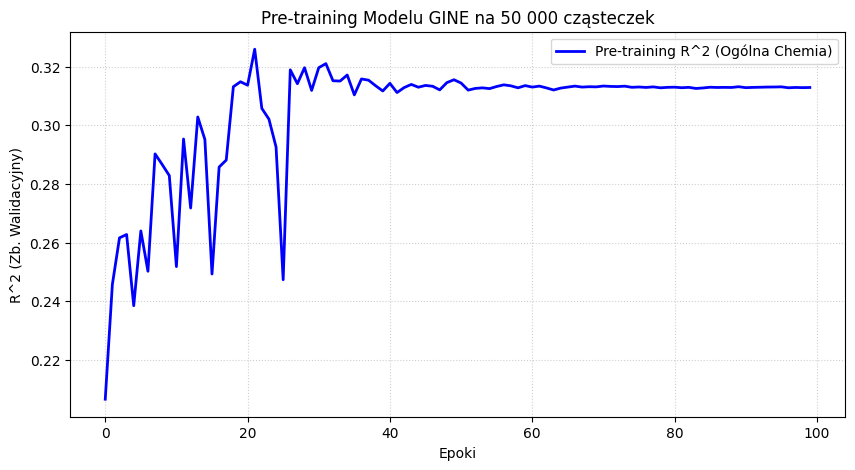


🏆 MAX R2 podczas Pre-trainingu: 0.3260
✅ Operacja zakończona!


In [ ]:
# ==============================================================================
# 22. PRE-TRAINING (ETAP 2): NAUCZANIE JĘZYKA CHEMII (100 EPOK + CHECKPOINTING)
# ==============================================================================
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from sklearn.metrics import r2_score
import numpy as np

print("\n🚀 Rozpoczynam morderczy trening wstępny (Pre-training) na 50 000 cząsteczek...")

new_tab_dim_pre = train_g_pre[0].tabular_x.shape[1]
print(f"Wymiar wejściowy warstwy MLP: {new_tab_dim_pre}")

model_pretrained = HybridGINE(
    num_node_features=7,
    num_edge_features=5,
    num_tabular_features=new_tab_dim_pre
)

# Nadpisujemy lekko funkcję trenującą, by ZAPISYWAŁA NAJLEPSZY MODEL NA BIEŻĄCO
def train_eval_gine_with_checkpoints(model, train_loader, val_loader, epochs=100, lr=0.001, save_path='gine_morgan_pretrained_50k.pth'):
    criterion = torch.nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    history = {'train_loss': [], 'val_loss': [], 'val_r2': []}
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    best_r2 = -float('inf') # Śledzimy najlepszy R2

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            predictions = model(data.x, data.edge_index, data.edge_attr, data.batch, data.tabular_x)
            loss = criterion(predictions, data.y.view(-1, 1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * data.num_graphs

        train_loss = train_loss / len(train_loader.dataset)
        history['train_loss'].append(train_loss)

        model.eval()
        val_loss = 0.0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                predictions = model(data.x, data.edge_index, data.edge_attr, data.batch, data.tabular_x)
                loss = criterion(predictions, data.y.view(-1, 1))
                val_loss += loss.item() * data.num_graphs
                all_preds.extend(predictions.cpu().numpy())
                all_targets.extend(data.y.view(-1, 1).cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        history['val_loss'].append(val_loss)

        current_r2 = r2_score(np.array(all_targets), np.array(all_preds))
        history['val_r2'].append(current_r2)

        scheduler.step(val_loss)

        # --- CHECKPOINTING (Zapisujemy tylko jeśli jest poprawa) ---
        if current_r2 > best_r2:
            best_r2 = current_r2
            torch.save(model.state_dict(), save_path)
            mark = " 🌟 (ZAPISANO NOWY NAJLEPSZY MODEL)"
        else:
            mark = ""

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoka {epoch+1:03d}/{epochs} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val R2: {current_r2:.4f}{mark}")

    return history

# Uruchamiamy nową, bezpieczną pętlę na 100 epok!
history_pretrained = train_eval_gine_with_checkpoints(
    model_pretrained,
    loader_train_pre,
    loader_val_pre,
    epochs=100,
    save_path='gine_morgan_pretrained_50k.pth'
)

# Wizualizacja procesu (Jeśli dotrwasz do końca bez rozłączenia Colaba)
plt.figure(figsize=(10, 5))
plt.plot(history_pretrained['val_r2'], label='Pre-training R^2 (Ogólna Chemia)', color='blue', linewidth=2)
plt.title('Pre-training Modelu GINE na 50 000 cząsteczek')
plt.xlabel('Epoki')
plt.ylabel('R^2 (Zb. Walidacyjny)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("\n" + "="*50)
print(f"🏆 MAX R2 podczas Pre-trainingu: {max(history_pretrained['val_r2']):.4f}")
print("="*50)
print("✅ Operacja zakończona!")

⏳ Przygotowanie Danych (Eksperyment Apples-to-Apples)...
⏳ Budowanie 3 równoległych wariantów grafów...

🚀 [1/3] Trenowanie: Czysta Topologia...
🔥 Trenuję hybrydowy GINE na urządzeniu: cuda
Epoka 001/25 | LR: 0.001000 | Train Loss: 6.8752 | Val Loss: 4.3312 | Val R2: -1.3258
Epoka 005/25 | LR: 0.001000 | Train Loss: 2.5596 | Val Loss: 4.2017 | Val R2: -1.2562
Epoka 010/25 | LR: 0.001000 | Train Loss: 1.8834 | Val Loss: 2.0403 | Val R2: -0.0956
Epoka 015/25 | LR: 0.001000 | Train Loss: 1.7876 | Val Loss: 1.8852 | Val R2: -0.0123
Epoka 020/25 | LR: 0.001000 | Train Loss: 1.7144 | Val Loss: 1.4895 | Val R2: 0.2002
Epoka 025/25 | LR: 0.001000 | Train Loss: 1.7915 | Val Loss: 1.6007 | Val R2: 0.1405

🚀 [2/3] Trenowanie: Topologia + Morgan...
🔥 Trenuję hybrydowy GINE na urządzeniu: cuda
Epoka 001/25 | LR: 0.001000 | Train Loss: 6.6030 | Val Loss: 3.6199 | Val R2: -0.9438
Epoka 005/25 | LR: 0.001000 | Train Loss: 1.9942 | Val Loss: 1.6811 | Val R2: 0.0973
Epoka 010/25 | LR: 0.001000 | Train L

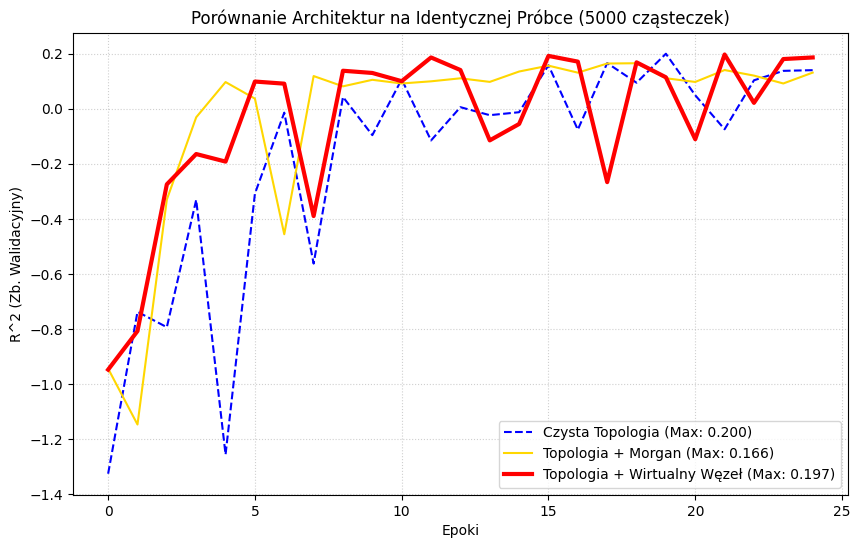

In [30]:
# ==============================================================================
# EKSPERYMENT: CZYSTA TOPOLOGIA vs MORGAN vs VIRTUAL NODE (Na identycznej próbce)
# ==============================================================================
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import VirtualNode
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

print("⏳ Przygotowanie Danych (Eksperyment Apples-to-Apples)...")

# 1. Losujemy bazową próbkę (5000 cząsteczek)
df_exp = df_all.sample(n=5000, random_state=42).copy()
ignore_cols = ['canonical_smiles', 'target', 'graph_data', 'chembl_id']
feature_cols = [c for c in df_exp.columns if c not in ignore_cols]
for col in feature_cols:
    df_exp[col] = pd.to_numeric(df_exp[col], errors='coerce').fillna(0.0)

# Narzędzia
add_virtual_node = VirtualNode()
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

# Listy na 3 warianty
data_list_pure = []
data_list_morgan = []
data_list_vn = []

print("⏳ Budowanie 3 równoległych wariantów grafów...")
for idx, row in df_exp.iterrows():
    smiles = row['canonical_smiles']
    target = row['target']

    # Podstawowe cechy (21)
    tab_x_pure = row[feature_cols].values.astype(float)

    mol = Chem.MolFromSmiles(smiles)
    if not mol: continue

    # Węzły
    node_features = []
    for atom in mol.GetAtoms():
        feat = [atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
                atom.GetNumRadicalElectrons(), atom.GetHybridization().real,
                int(atom.GetIsAromatic()), atom.GetMass()]
        node_features.append(feat)
    x = torch.tensor(node_features, dtype=torch.float32)

    # Krawędzie
    edge_indices, edge_attrs = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        b_type = bond.GetBondType()
        bond_feat = [
            float(b_type == Chem.rdchem.BondType.SINGLE), float(b_type == Chem.rdchem.BondType.DOUBLE),
            float(b_type == Chem.rdchem.BondType.TRIPLE), float(b_type == Chem.rdchem.BondType.AROMATIC),
            float(bond.GetIsConjugated())
        ]
        edge_indices += [[i, j], [j, i]]
        edge_attrs += [bond_feat, bond_feat]

    if len(edge_indices) > 0:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.float32)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 5), dtype=torch.float32)

    y = torch.tensor([[target]], dtype=torch.float32)

    # Wariant 1: Pure
    tab_tensor_pure = torch.tensor([tab_x_pure], dtype=torch.float32)
    data_pure = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, tabular_x=tab_tensor_pure)

    # Wariant 2: Morgan
    morgan_fp = np.array(mfpgen.GetFingerprint(mol), dtype=float)
    tab_x_morgan = np.concatenate([tab_x_pure, morgan_fp])
    tab_tensor_morgan = torch.tensor([tab_x_morgan], dtype=torch.float32)
    data_morgan = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, tabular_x=tab_tensor_morgan)

    # Wariant 3: Virtual Node
    data_vn = add_virtual_node(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, tabular_x=tab_tensor_pure))

    data_list_pure.append(data_pure)
    data_list_morgan.append(data_morgan)
    data_list_vn.append(data_vn)

# 2. IDENTYCZNY PODZIAŁ (Klucz do testu A/B)
indices = list(range(len(data_list_pure)))
train_idx, val_idx = train_test_split(indices, test_size=0.1, random_state=42)

train_pure, val_pure = [data_list_pure[i] for i in train_idx], [data_list_pure[i] for i in val_idx]
train_morgan, val_morgan = [data_list_morgan[i] for i in train_idx], [data_list_morgan[i] for i in val_idx]
train_vn, val_vn = [data_list_vn[i] for i in train_idx], [data_list_vn[i] for i in val_idx]

# Loadery
batch_s = 128
l_train_pure, l_val_pure = DataLoader(train_pure, batch_size=batch_s, shuffle=True), DataLoader(val_pure, batch_size=batch_s)
l_train_morgan, l_val_morgan = DataLoader(train_morgan, batch_size=batch_s, shuffle=True), DataLoader(val_morgan, batch_size=batch_s)
l_train_vn, l_val_vn = DataLoader(train_vn, batch_size=batch_s, shuffle=True), DataLoader(val_vn, batch_size=batch_s)

# 3. TRENING (Dla szybkości: 25 Epok)
epochs = 25
print("\n🚀 [1/3] Trenowanie: Czysta Topologia...")
m_pure = HybridGINE(7, 5, len(feature_cols))
h_pure = train_eval_gine(m_pure, l_train_pure, l_val_pure, epochs=epochs)

print("\n🚀 [2/3] Trenowanie: Topologia + Morgan...")
m_morgan = HybridGINE(7, 5, len(feature_cols) + 1024)
h_morgan = train_eval_gine(m_morgan, l_train_morgan, l_val_morgan, epochs=epochs)

print("\n🚀 [3/3] Trenowanie: Topologia + Wirtualny Węzeł...")
m_vn = HybridGINE(7, 5, len(feature_cols))
h_vn = train_eval_gine(m_vn, l_train_vn, l_val_vn, epochs=epochs)

# 4. WIZUALIZACJA
plt.figure(figsize=(10, 6))
plt.plot(h_pure['val_r2'], label=f'Czysta Topologia (Max: {max(h_pure["val_r2"]):.3f})', color='blue', linestyle='--')
plt.plot(h_morgan['val_r2'], label=f'Topologia + Morgan (Max: {max(h_morgan["val_r2"]):.3f})', color='gold')
plt.plot(h_vn['val_r2'], label=f'Topologia + Wirtualny Węzeł (Max: {max(h_vn["val_r2"]):.3f})', color='red', linewidth=3)

plt.title('Porównanie Architektur na Identycznej Próbce (5000 cząsteczek)')
plt.xlabel('Epoki')
plt.ylabel('R^2 (Zb. Walidacyjny)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

⏳ Przygotowanie Danych (Eksperyment Apples-to-Apples dla BACE1)...
⏳ Budowanie 3 równoległych wariantów grafów dla 12097 cząsteczek BACE1...

🚀 [1/3] Trenowanie: Czysta Topologia na BACE1...
🔥 Trenuję hybrydowy GINE na urządzeniu: cuda
Epoka 001/50 | LR: 0.001000 | Train Loss: 3.1553 | Val Loss: 2.1340 | Val R2: -0.3698
Epoka 005/50 | LR: 0.001000 | Train Loss: 1.2876 | Val Loss: 0.9949 | Val R2: 0.3614
Epoka 010/50 | LR: 0.001000 | Train Loss: 1.1635 | Val Loss: 0.8556 | Val R2: 0.4508
Epoka 015/50 | LR: 0.001000 | Train Loss: 1.0381 | Val Loss: 1.1504 | Val R2: 0.2616
Epoka 020/50 | LR: 0.000500 | Train Loss: 0.9617 | Val Loss: 0.8587 | Val R2: 0.4488
Epoka 025/50 | LR: 0.000500 | Train Loss: 0.9075 | Val Loss: 0.8273 | Val R2: 0.4689
Epoka 030/50 | LR: 0.000500 | Train Loss: 0.8580 | Val Loss: 0.9191 | Val R2: 0.4100
Epoka 035/50 | LR: 0.000250 | Train Loss: 0.8176 | Val Loss: 0.7232 | Val R2: 0.5358
Epoka 040/50 | LR: 0.000250 | Train Loss: 0.8024 | Val Loss: 0.7041 | Val R2: 0.548

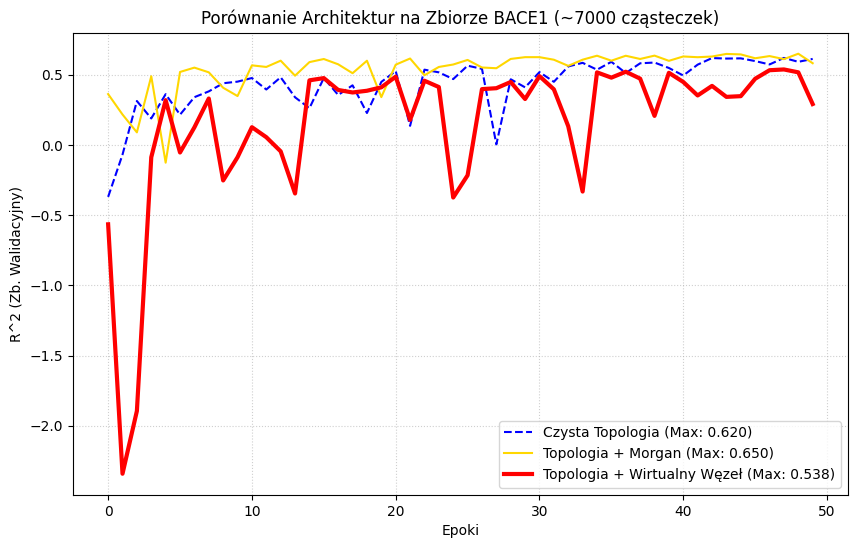

In [33]:
# ==============================================================================
# EKSPERYMENT DOCELOWY: BACE1 - CZYSTA TOPOLOGIA vs MORGAN vs VIRTUAL NODE
# ==============================================================================
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import VirtualNode
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

print("⏳ Przygotowanie Danych (Eksperyment Apples-to-Apples dla BACE1)...")

# --- Wczytanie danych BACE1 ---
# UWAGA: Upewnij się, że df_bace1 to Twoja ramka z danymi BACE1!
# Jeśli ładujesz z pliku: df_bace1 = pd.read_csv('bace1_data.csv')
df_exp = df_bace.copy()

ignore_cols = ['canonical_smiles', 'target', 'graph_data', 'chembl_id', 'pIC50'] # ignoruj to co nie jest cechą
# Upewniamy się, że przewidujemy pIC50 (regresja)
target_col = 'target' if 'target' in df_exp.columns else 'pIC50'

feature_cols = [c for c in df_exp.columns if c not in ignore_cols]
for col in feature_cols:
    df_exp[col] = pd.to_numeric(df_exp[col], errors='coerce').fillna(0.0)

# Narzędzia
add_virtual_node = VirtualNode()
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

# Listy na 3 warianty
data_list_pure = []
data_list_morgan = []
data_list_vn = []

print(f"⏳ Budowanie 3 równoległych wariantów grafów dla {len(df_exp)} cząsteczek BACE1...")
for idx, row in df_exp.iterrows():
    smiles = row['canonical_smiles']
    target_val = row[target_col]

    # Podstawowe cechy
    tab_x_pure = row[feature_cols].values.astype(float)

    mol = Chem.MolFromSmiles(smiles)
    if not mol: continue

    # Węzły
    node_features = []
    for atom in mol.GetAtoms():
        feat = [atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
                atom.GetNumRadicalElectrons(), atom.GetHybridization().real,
                int(atom.GetIsAromatic()), atom.GetMass()]
        node_features.append(feat)
    x = torch.tensor(node_features, dtype=torch.float32)

    # Krawędzie
    edge_indices, edge_attrs = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        b_type = bond.GetBondType()
        bond_feat = [
            float(b_type == Chem.rdchem.BondType.SINGLE), float(b_type == Chem.rdchem.BondType.DOUBLE),
            float(b_type == Chem.rdchem.BondType.TRIPLE), float(b_type == Chem.rdchem.BondType.AROMATIC),
            float(bond.GetIsConjugated())
        ]
        edge_indices += [[i, j], [j, i]]
        edge_attrs += [bond_feat, bond_feat]

    if len(edge_indices) > 0:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.float32)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 5), dtype=torch.float32)

    y = torch.tensor([[target_val]], dtype=torch.float32)

    # Wariant 1: Pure
    tab_tensor_pure = torch.tensor([tab_x_pure], dtype=torch.float32)
    data_pure = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, tabular_x=tab_tensor_pure)

    # Wariant 2: Morgan
    morgan_fp = np.array(mfpgen.GetFingerprint(mol), dtype=float)
    tab_x_morgan = np.concatenate([tab_x_pure, morgan_fp])
    tab_tensor_morgan = torch.tensor([tab_x_morgan], dtype=torch.float32)
    data_morgan = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, tabular_x=tab_tensor_morgan)

    # Wariant 3: Virtual Node
    data_vn = add_virtual_node(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, tabular_x=tab_tensor_pure))

    data_list_pure.append(data_pure)
    data_list_morgan.append(data_morgan)
    data_list_vn.append(data_vn)

# 2. IDENTYCZNY PODZIAŁ (Dla testu szybki Random Split)
indices = list(range(len(data_list_pure)))
train_idx, val_idx = train_test_split(indices, test_size=0.1, random_state=42)

train_pure, val_pure = [data_list_pure[i] for i in train_idx], [data_list_pure[i] for i in val_idx]
train_morgan, val_morgan = [data_list_morgan[i] for i in train_idx], [data_list_morgan[i] for i in val_idx]
train_vn, val_vn = [data_list_vn[i] for i in train_idx], [data_list_vn[i] for i in val_idx]

batch_s = 128
l_train_pure, l_val_pure = DataLoader(train_pure, batch_size=batch_s, shuffle=True), DataLoader(val_pure, batch_size=batch_s)
l_train_morgan, l_val_morgan = DataLoader(train_morgan, batch_size=batch_s, shuffle=True), DataLoader(val_morgan, batch_size=batch_s)
l_train_vn, l_val_vn = DataLoader(train_vn, batch_size=batch_s, shuffle=True), DataLoader(val_vn, batch_size=batch_s)

# 3. TRENING (Zwiększamy do 35 epok, bo cel jest konkretniejszy)
epochs = 50
print(f"\n🚀 [1/3] Trenowanie: Czysta Topologia na BACE1...")
m_pure = HybridGINE(7, 5, len(feature_cols))
h_pure = train_eval_gine(m_pure, l_train_pure, l_val_pure, epochs=epochs)

print(f"\n🚀 [2/3] Trenowanie: Topologia + Morgan na BACE1...")
m_morgan = HybridGINE(7, 5, len(feature_cols) + 1024)
h_morgan = train_eval_gine(m_morgan, l_train_morgan, l_val_morgan, epochs=epochs)

print(f"\n🚀 [3/3] Trenowanie: Topologia + Wirtualny Węzeł na BACE1...")
m_vn = HybridGINE(7, 5, len(feature_cols))
h_vn = train_eval_gine(m_vn, l_train_vn, l_val_vn, epochs=epochs)

# 4. WIZUALIZACJA
plt.figure(figsize=(10, 6))
plt.plot(h_pure['val_r2'], label=f'Czysta Topologia (Max: {max(h_pure["val_r2"]):.3f})', color='blue', linestyle='--')
plt.plot(h_morgan['val_r2'], label=f'Topologia + Morgan (Max: {max(h_morgan["val_r2"]):.3f})', color='gold')
plt.plot(h_vn['val_r2'], label=f'Topologia + Wirtualny Węzeł (Max: {max(h_vn["val_r2"]):.3f})', color='red', linewidth=3)

plt.title('Porównanie Architektur na Zbiorze BACE1 (~7000 cząsteczek)')
plt.xlabel('Epoki')
plt.ylabel('R^2 (Zb. Walidacyjny)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()